# Image Classification Baselines

This notebook establishes non-neural image-classification baselines before learned feature
representations are introduced. It begins with simple MNIST classifiers and then expands to
k-nearest neighbors across MNIST, Fashion-MNIST, and CIFAR-10.

The experiments cover:

- Constant-class baselines
- ZeroR
- One-nearest-neighbor
- Naive and vectorized distance computation
- k-nearest neighbors
- Attribute-order invariance
- Principal component analysis
- Cross-dataset performance comparison

## 1. MNIST: Simple Classification Strategies

### 1.1 Load MNIST

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


### 1.2 Preprocessing

Reshape to 2D array, rescale to 0-1 range, and convert to floating point.

In [3]:
x_train = np.float32(x_train.reshape(x_train.shape[0],-1)/255)
x_test = np.float32(x_test.reshape(x_test.shape[0],-1)/255)

### 1.3 Visualize Training Examples

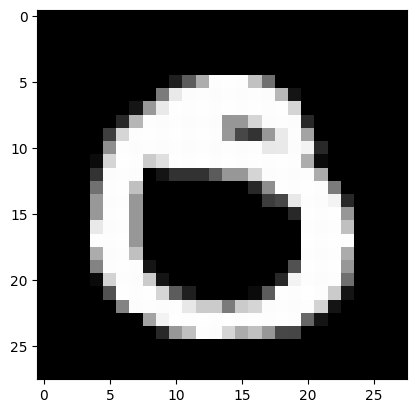

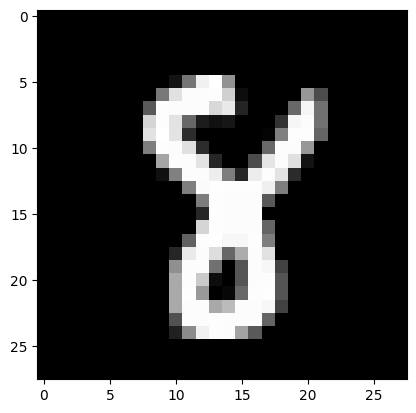

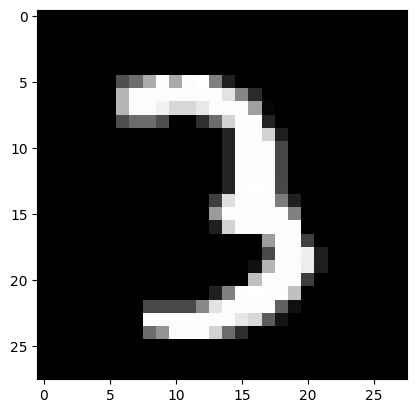

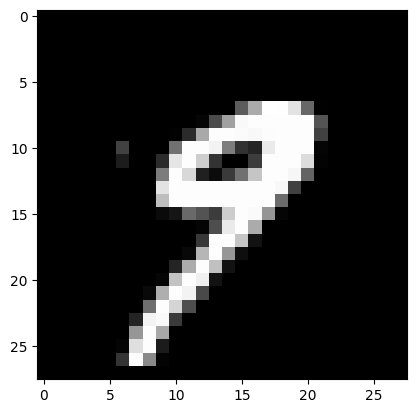

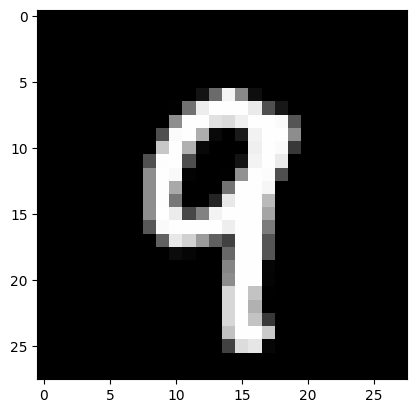

In [4]:
for i in range(5):
  plt.figure()
  im = np.random.randint(0,x_train.shape[0])
  plt.imshow(x_train[im].reshape(28,28),cmap='gray')

### 1.4 Constant-Class Baseline

In [5]:
def accuracy(y_test, pred):
    return np.mean(y_test==pred)

In [6]:
class model1:

    def __init__(self): # Constructor
        pass

    def fit(self,x_train, y_train): # Fit model parameters to training data
        pass

    def predict(self,x_test): # Predict class of test data
        return np.full(x_test.shape[0],0)

model = model1()
model.fit(x_train, y_train)
pred = model.predict(x_test)
print('Accuracy = {:6.3f}'.format(accuracy(y_test, pred)))
print('Results for first 30 test examples')
print('Actual class:',y_test[:30])
print('Predictions:', pred[:30])

Accuracy =  0.098
Results for first 30 test examples
Actual class: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 1.5 ZeroR Baseline

In [7]:
class model2:

    def __init__(self): # Constructor
        pass

    def fit(self,x_train, y_train): # Fit model parameters to training data
        count = np.zeros(np.max(y_train)+1,np.int16)
        for y in y_train:
          count[y] +=1
        self.most_common_class = np.argmax(count)

    def predict(self,x_test): # Predict class of test data
        #return np.random.randint(0,10,size=x_test.shape[0])
        return np.full(x_test.shape[0],self.most_common_class)

model = model2()
model.fit(x_train, y_train)
pred = model.predict(x_test)
print('Accuracy = {:6.4f}'.format(accuracy(y_test, pred)))
print('Results for first 30 test examples')
print('Actual class:',y_test[:30])
print('Predictions: ', pred[:30])

Accuracy = 0.1135
Results for first 30 test examples
Actual class: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Predictions:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### 1.6 One-Nearest-Neighbor

#### Direct Distance Computation

In [8]:
class model3:

    def __init__(self): # Constructor
        pass

    def fit(self,x_train, y_train): # Fit model parameters to training data
        self.x_train = x_train
        self.y_train = y_train

    def predict(self,x_test): # Predict class of test data
        pred = np.zeros(x_test.shape[0],np.uint8)
        x_test = x_test
        for i in range(x_test.shape[0]):
          diff = x_test[i] - self.x_train
          #print(diff.shape)
          dist = np.sum(diff**2,axis=1)**(0.5)
          #print(dist.shape)
          c = np.argmin(dist)
          pred[i] = self.y_train[c]
        return pred

m = 10
n = 10
start = time.time()
model = model3()
model.fit(x_train[::m], y_train[::m])
pred = model.predict(x_test[::n])
end_test = time.time()
print('Accuracy = {:6.4f}'.format(accuracy(y_test[::n], pred)))
print('Results for first 30 test examples')
print('Actual class:',y_test[::n][:30])
print('Predictions: ', pred[:30])
print('Total elapsed time = {:.4f} secs'.format(end_test-start))
print('Test set size:',len(y_test[::n]))


Accuracy = 0.9380
Results for first 30 test examples
Actual class: [7 0 9 3 1 6 7 7 7 3 6 8 5 6 6 9 4 4 1 1 3 4 7 3 5 4 8 3 2 8]
Predictions:  [7 0 9 3 1 6 7 7 7 3 6 8 5 6 6 9 4 9 1 1 3 4 7 3 5 4 5 3 2 8]
Total elapsed time = 16.4175 secs
Test set size: 1000


#### Vectorized Distance Computation: $(a-b)^2 = a^2 - 2ab + b^2$

In [9]:
class model3b:

    def __init__(self): # Constructor
        pass

    def fit(self,x_train, y_train): # Fit model parameters to training data
        self.x_train = x_train
        self.y_train = y_train

    def predict(self,x_test): # Predict class of test data
        # Improved version using the fact that (a-b)**2 = a**2 - 2ab + b**c
        dist = np.sum(x_test**2,axis=1,keepdims=True)
        print(dist.shape)
        dist = dist - 2*np.matmul(x_test,self.x_train.T)
        print(dist.shape)
        dist += np.sum(self.x_train.T**2,axis=0,keepdims=True)
        print(dist.shape)
        nn = np.argmin(dist,axis=1)
        return self.y_train[nn]

m = 1
n = 1
start = time.time()
model = model3b()
model.fit(x_train[::m], y_train[::m])
pred = model.predict(x_test[::n])
end_test = time.time()
print('Accuracy = {:6.4f}'.format(accuracy(y_test[::n], pred)))
print('Results for first 30 test examples')
print('Actual class:',y_test[::n][:30])
print('Predictions: ', pred[:30])
print('Total elapsed time = {:.4f} secs'.format(end_test-start))
print('Test set size:',len(y_test[::n]))

(10000, 1)
(10000, 60000)
(10000, 60000)
Accuracy = 0.9691
Results for first 30 test examples
Actual class: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Predictions:  [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Total elapsed time = 10.3655 secs
Test set size: 10000


## 2. k-Nearest Neighbors Across Multiple Image Datasets

The same distance-based classifier is now applied to MNIST, Fashion-MNIST, and CIFAR-10.
This provides a useful comparison as the visual complexity of the data increases.

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

### 2.1 Dataset Loader

In [11]:
def load_dataset(dataset_name):
  if dataset_name in ['MNIST','Fashion-MNIST']:
    if dataset_name =='MNIST':
      (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    else:
      (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    # add empty color dimension and scale to [0,1]
    x_train = np.float32(np.expand_dims(x_train, -1)/255)
    x_test = np.float32(np.expand_dims(x_test, -1)/255)
  elif dataset_name == 'CIFAR-10':
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype('float32') / 255
    x_test = x_test.astype('float32') / 255
  else:
    print('Unknown dataset')
    return
  #y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
  #y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
  return x_train, y_train, x_test, y_test

### 2.2 Visualize Random Samples

In [12]:
def show_imgs(x_train,n):
  sel = np.random.randint(0,x_train.shape[0],size = n)
  fig, ax = plt.subplots(1,len(sel),figsize=(16, 8))
  for i,s in enumerate(sel):
    if x_train.shape[2] == 3:
      ax[i].imshow(x_train[s])
    else:
      ax[i].imshow(np.squeeze(x_train[s]),cmap='gray')
    ax[i].axis('off')

### 2.3 Distance-Weighted k-NN

A distance-weighted 5-neighbor classifier is evaluated on all three datasets.

MNIST
Accuracy 0.9691
Fashion-MNIST
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Accuracy 0.8577
CIFAR-10
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1285s 8us/step


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy 0.3567


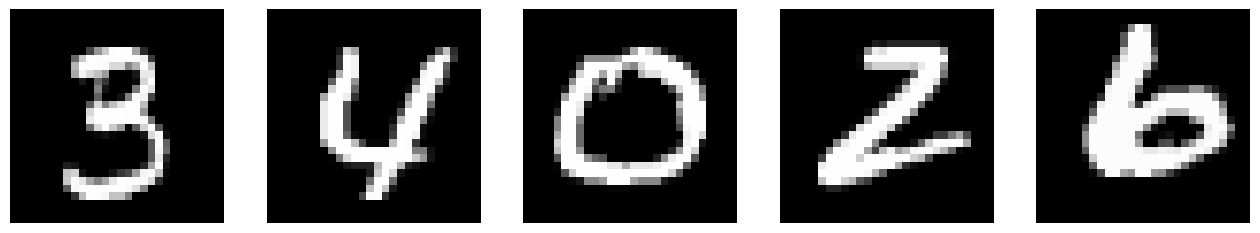

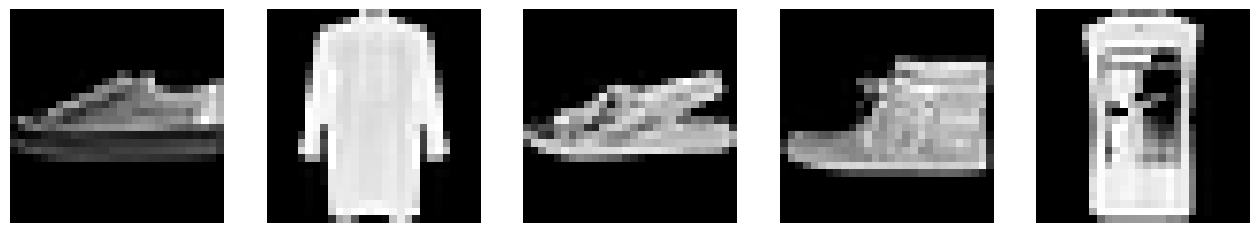

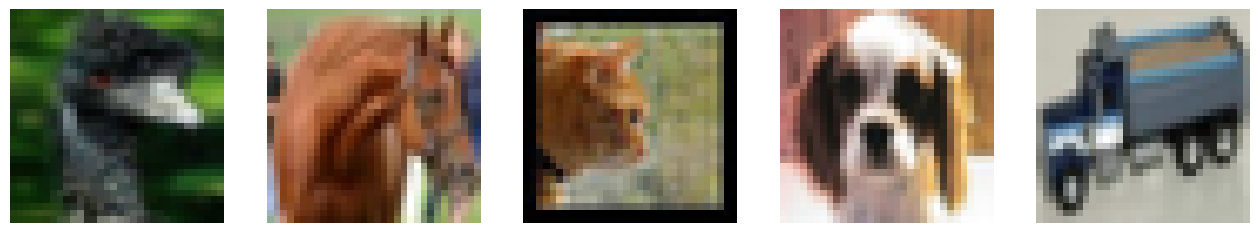

In [13]:
for dataset_name in ['MNIST', 'Fashion-MNIST', 'CIFAR-10']:
  print(dataset_name)
  x_train, y_train, x_test, y_test = load_dataset(dataset_name)
  show_imgs(x_train,5)
  x_train = x_train.reshape(x_train.shape[0],-1)
  x_test = x_test.reshape(x_test.shape[0],-1)

  model =  KNeighborsClassifier(n_neighbors=5, algorithm='brute', weights='distance', n_jobs=-1)
  model.fit(x_train, y_train)
  pred = model.predict(x_test)

  accuracy = accuracy_score(y_test, pred)
  print(f'Accuracy {accuracy:.4}')


### 2.4 Attribute-Order Invariance

In [14]:
for dataset_name in ['MNIST', 'Fashion-MNIST', 'CIFAR-10']:
  print(dataset_name)
  x_train, y_train, x_test, y_test = load_dataset(dataset_name)
  #show_imgs(x_train,5)
  x_train = x_train.reshape(x_train.shape[0],-1)
  x_test = x_test.reshape(x_test.shape[0],-1)
  rp = np.random.permutation(x_train.shape[1])
  x_train = x_train[:,rp]
  x_test = x_test[:,rp]

  model =  KNeighborsClassifier(n_neighbors=5, algorithm='brute', weights='distance', n_jobs=-1)
  model.fit(x_train, y_train)
  pred = model.predict(x_test)

  accuracy = accuracy_score(y_test, pred)
  print(f'Accuracy {accuracy:.4}')

MNIST
Accuracy 0.9691
Fashion-MNIST
Accuracy 0.8577
CIFAR-10


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy 0.3567


### 2.5 Principal Component Analysis

MNIST
Accuracy 0.9759
Fashion-MNIST
Accuracy 0.8628
CIFAR-10


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy 0.4081


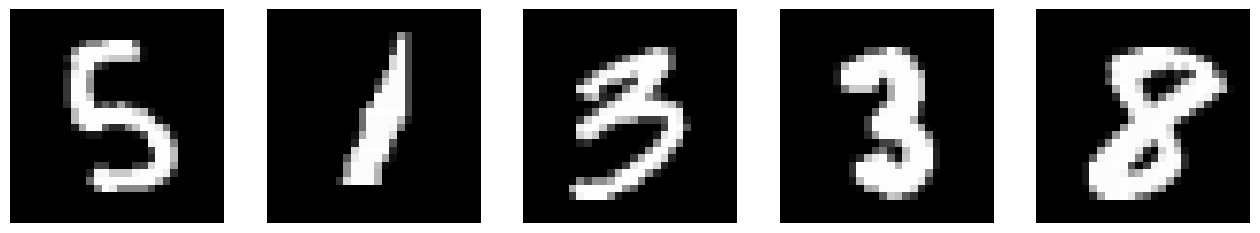

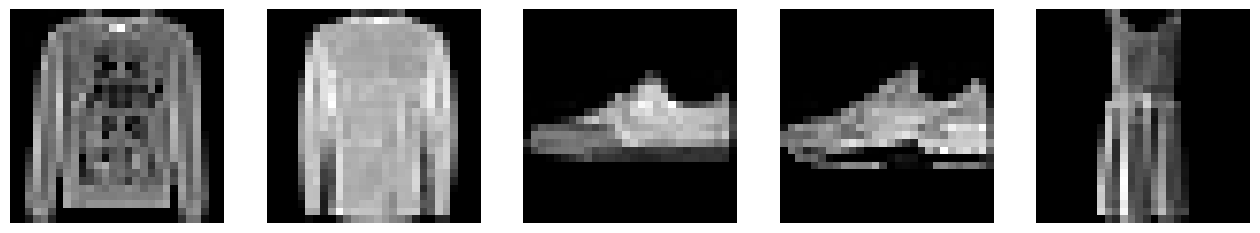

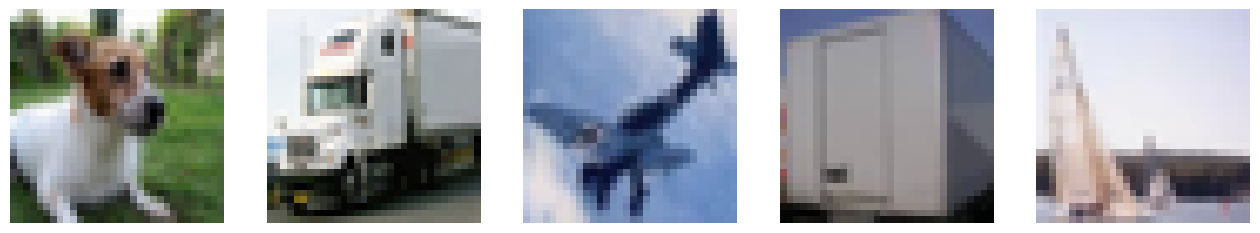

In [15]:
from sklearn.decomposition import PCA

for dataset_name in ['MNIST', 'Fashion-MNIST', 'CIFAR-10']:
  print(dataset_name)
  x_train, y_train, x_test, y_test = load_dataset(dataset_name)
  show_imgs(x_train,5)
  x_train = x_train.reshape(x_train.shape[0],-1)
  x_test = x_test.reshape(x_test.shape[0],-1)

  n_components = 64
  pca = PCA(n_components=n_components)
  pca.fit(x_train)
  x_train = pca.transform(x_train)
  x_test = pca.transform(x_test)

  model =  KNeighborsClassifier(n_neighbors=5, algorithm='brute', weights='distance', n_jobs=-1)
  model.fit(x_train, y_train)
  pred = model.predict(x_test)

  accuracy = accuracy_score(y_test, pred)
  print(f'Accuracy {accuracy:.4}')

## 3. Interpretation

The progression from MNIST to Fashion-MNIST and CIFAR-10 illustrates an important limitation of
raw-pixel distance. The method is highly effective on simple digit images but becomes less
competitive as image appearance, color, texture, and intra-class variability increase. PCA and
the attribute-shuffling experiment further separate geometric distance behavior from image
spatial structure.